<figure>
    <picture>
        <source srcset="assets/jii-logo.png" style="max-height: 10rem;">
        <img src="https://raw.githubusercontent.com/Computational-Biology-Aachen/2026-photosynthesis-hackathon-template/refs/heads/main/assets/jii-logo.png" style="max-height: 10rem;">
    </picture>
</figure>




# Grebbedijk potato

This notebook contains example analysis for the Grebbedijk potato data kindly supplied by the JII

|                        |                                  |
| ---------------------- | -------------------------------- |
| **Crop**               | Potato                           |
| **Location**           | Wageningen, Netherlands          |
| **Year**               | 2025                             |
| **Measurements**       | 3,681                            |
| **Genotypes**          | 48 plots                         |
| **Owner**              | Olivia Kacheyo                   |
| **Protocol**           | UNZA_PIRK_DIRK_LightPotential_14 |
| **PhotosynQ projects** | 33338                            |

**Experiment:** Assessment of photosynthesis dynamics in a potato field trial at Grebbedijk (Wageningen). 48 plots measured with MultispeQ, genotype assigned via plot layout key.

**Protocol features (UNZA_PIRK_DIRK):** This protocol measures photosynthesis under both ambient and high (saturating) actinic light, enabling calculation of "light potential" — the difference between current and maximum electron transport rate. It also includes PIRK (Post-Illumination Rise in fluorescence Kinetics), an indicator of cyclic electron flow around PSI.

**Computed columns (25):**

| Category       | Columns                                                                                                                                          |
| -------------- | ------------------------------------------------------------------------------------------------------------------------------------------------ |
| Photosynthesis | `phi2_ambient`, `phi2_high`, `LEF_ambient`, `LEF_high`, `LEF_light_potential`                                                                    |
| Light          | `PAR`, `used_PAR_ambient`, `used_PAR_high`, `SQRT_PAR`                                                                                           |
| Chlorophyll    | `SPAD`                                                                                                                                           |
| Environment    | `ambient_Temperature`, `leaf_temperature`, `leaf_temperature_differential`, `humidity`, `pressure`, `leaf_angle`                                 |
| PIRK           | `PIRK_amp_ambient`, `PIRK_amp_high`, `pirk_intensity`                                                                                            |
| Autogain       | `autogain_ch1_duration`, `autogain_ch1_intensity`, `autogain_ch1_value`, `autogain_ch2_duration`, `autogain_ch2_intensity`, `autogain_ch2_value` |
| Timing         | `measurement_duration_sec`                                                                                                                       |

**Additional column:** `sample_raw` (VARIANT) — full raw measurement trace from the MultispeQ device, containing time-resolved fluorescence, absorbance, and environmental sensor data. Can be parsed for additional phenotypes beyond the computed columns.

In [3]:
from pathlib import Path
from typing import Any

import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cartopy import crs

from src.data import load_grebbedijk

df = load_grebbedijk(Path("data"))

## Analyse distribution of data

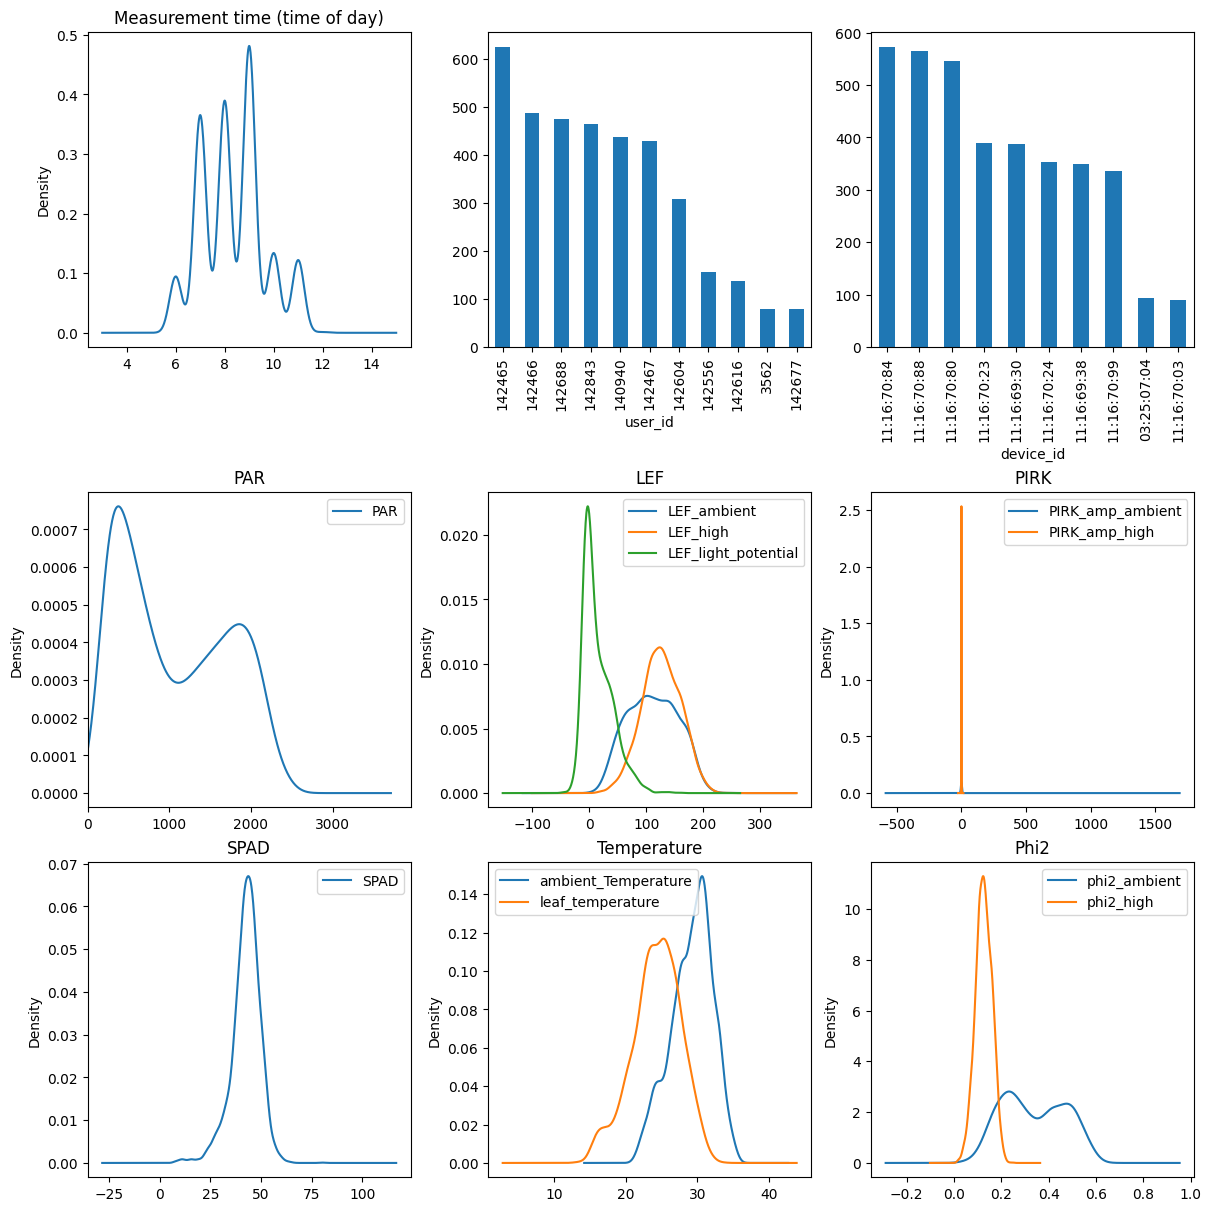

In [4]:
fig, axs = plt.subplots(3, 3, figsize=(12, 12), layout="constrained")
ai = iter(axs.flatten())

# Time of day
ax = df["timestamp"].dt.hour.plot(kind="kde", ax=next(ai))
ax.set(title="Measurement time (time of day)")

# User id
df["user_id"].value_counts().plot(kind="bar", ax=next(ai))

# Device id
df["device_id"].value_counts().plot(kind="bar", ax=next(ai))

# PAR
ax = df.loc[:, ["PAR"]].plot(kind="kde", title="PAR", xlim=(0, None), ax=next(ai))

# Linear electron flow
ax = df.loc[:, ["LEF_ambient", "LEF_high", "LEF_light_potential"]].plot(
    kind="kde", title="LEF", ax=next(ai)
)

# PIRK
ax = df.loc[:, ["PIRK_amp_ambient", "PIRK_amp_high"]].plot(
    kind="kde", title="PIRK", ax=next(ai)
)

# SPAD
ax = df.loc[:, ["SPAD"]].plot(kind="kde", title="SPAD", ax=next(ai))

# Temperature
ax = df.loc[:, ["ambient_Temperature", "leaf_temperature"]].plot(
    kind="kde", title="Temperature", ax=next(ai)
)

# Phi2
ax = df.loc[:, ["phi2_ambient", "phi2_high"]].plot(
    kind="kde", title="Phi2", ax=next(ai)
)

/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


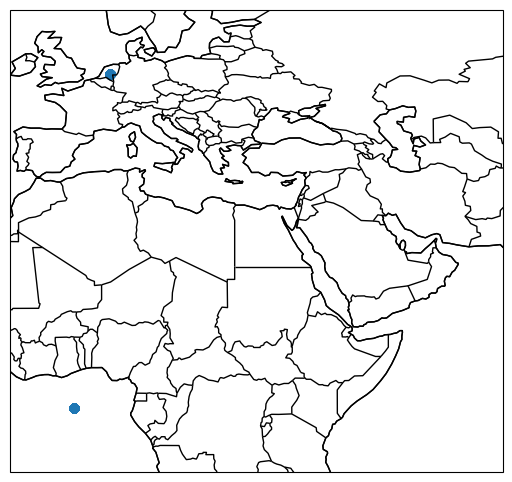

In [5]:
fig = plt.figure(figsize=(12, 6))
ax: Any = fig.add_subplot(projection=crs.PlateCarree())

ax.scatter(df["longitude"], df["latitude"], transform=crs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.set_extent(
    [
        df["longitude"].min() - 10,
        df["longitude"].max() * 10 + 10,
        df["latitude"].min() - 10,
        df["latitude"].max() + 10,
    ],
    crs=crs.PlateCarree(),
)

## Trace analysis

In [6]:
# Trace analysis requires parsing the `sample_raw` VARIANT column.
# This column contains the full raw measurement trace from the MultispeQ device.